# Hyperparameters and Model Validation
---
*Christian Jelo R. Artoza*

## Thinking About Model Validation

### Model validation the wrong way

In [6]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target

In [7]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=1)
model.fit(X, y)
y_model = model.predict(X)

In [8]:
from sklearn.metrics import accuracy_score
print('KNN accuracy score: ', accuracy_score(y, y_model))

KNN accuracy score:  1.0


This way of model validation is wrong for a couple of reasons. First, we trained and evaluated the model on the same data. We can address this by splitting the data into a training set and a test set.

Second, the KNN model is an *instance-based* estimator: It stores the training data, and predicts the label of unknown data by comparing it against each of the stored data. So, by using the same data for testing, we would be comparing the data with itself! Hence, we'll always get a score of 1.0.

### Model validation the right way: Holdout sets
A *holdout set* is a subset of the data that you set aside for validating the data. This is the same idea as splitting the data into a training set and a test set; the test set being the hold out set.

To do this, we can use Scikit-Learn's `test_train_split()` function.

In [19]:
from sklearn.model_selection import train_test_split
# Split the data into training set and test set
# By specifying train_size to 0.5, the data is split 50-50
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, train_size=0.5)

# Fit the model to the training data
model.fit(X_train, y_train)

# Predict unknown data: the test data (a.k.a. the holdout set)
# Data stored in X_test is unknown data for the model, since we did not use them for training
y_model = model.predict(X_test)

# Check the accuracy score
print('KNN accuracy score:', accuracy_score(y_test, y_model))

KNN accuracy score: 0.9066666666666666


### Model validation via cross-validation
The disadvantage of using holdout sets is that the test set does not contribute to the training of the model. This could become a problem especially when the dataset is small.

A way to address this is to use cross-validation. That is, to run a sequence of fits where each subset is used as training set and as validation set.

For instance, in the above example we split the dataset into two subsets `(X1,y1), (X2,y2)` (each containing half of `n_samples`). To use cross-validation, we run two trials where we use each subset as the training set and the validation set.
- Trial 1: Fit the model to `(X1,y1)` and use `(X2,y2)` for testing
- Trial 2: Fit the model to `(X2,y2)` and use `(X1,y1)` for testing

In [21]:
#Divide the dataset 50-50
X1, X2, y1, y2 = train_test_split(X,y, random_state=0, train_size=0.5)

#Fit the model to (X1,y1) and use (X2,y2) for testing
y_model = model.fit(X1,y1).predict(X2)
print('Accuracy score for trial 1:', accuracy_score(y2, y_model))

#Fit the model to (X2,y2) and use (X2,y2) for testing
y_model = model.fit(X2,y2).predict(X1)
print('Accuracy score for trial 2:', accuracy_score(y1, y_model))

Accuracy score for trial 1: 0.9066666666666666
Accuracy score for trial 2: 0.96


The result is a set of accuracy scores, one from each trial, which we could combine to get a better measure of the performance of the model.

The above example is called a two-fold cross-validation. Of course, we can split the data into more pieces.

For instance, a five-fold cross-validation means dividing the data into five subsets, and running a sequence of fits where one of the five is used as validation set and the remaining four are used as training. We do this until all subsets get a turn as the validation set.

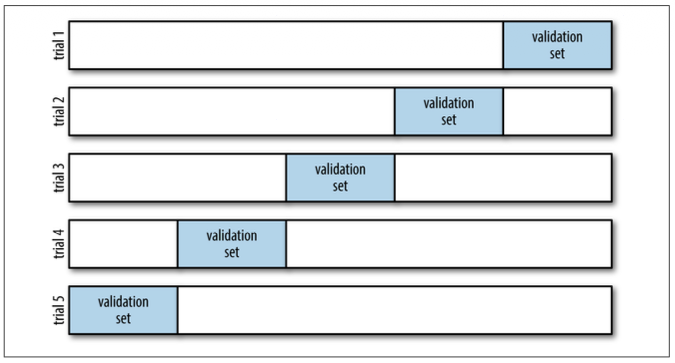

*Five-fold cross-validation (figure taken from the book)*

It would be tedious to write out the code for each trial. Fortunately Scikit-Learn has the `cross_val_score()` that we can use to get the scores from each trial!

In [27]:
from sklearn.model_selection import cross_val_score
print('Five-fold Cross Validation Results:')
for i,score in enumerate(cross_val_score(model, X, y, cv=5)):
    print(f'   Trial {i+1}: {score}')

Five-fold Cross Validation Results:
   Trial 1: 0.9666666666666667
   Trial 2: 0.9666666666666667
   Trial 3: 0.9333333333333333
   Trial 4: 0.9333333333333333
   Trial 5: 1.0


## Selecting the Best Model
When a model does not perform well on a given data, we may want to consider a wayforward similar to one of the following:
- Select a more complicated/more flexible model
- Select a less complicated/less flexible model
- Gather more samples
- Gather more features

Addressing the issue is more difficult than it looks. Sometimes using a more complicated model alone gives worse results, and gathering more samples alone may not improve the results.

### The bias-variance trade-off
> Fundamentally, the question of "the best model" is about finding a sweet spot in the trade-off between bias and variance.

A model is said to *underfit* the data if it does not have enough flexibility to account for all features of the data (e.g., A model attempting to fit a straight line to a data that is not naturally linear). Such a model is also said to have *high bias*.

At the other end of the spectrum, a model is said to *overfit* the data if it is so flexible that it ends up accounting the noise or random errors and the underlying data distribution. Such model is also said to have *high variance*.

Between a low-complexity model that underfits the data and a high-complexity model that overfits the data, there is a model with just the right complexity that provides the best fit for the data.

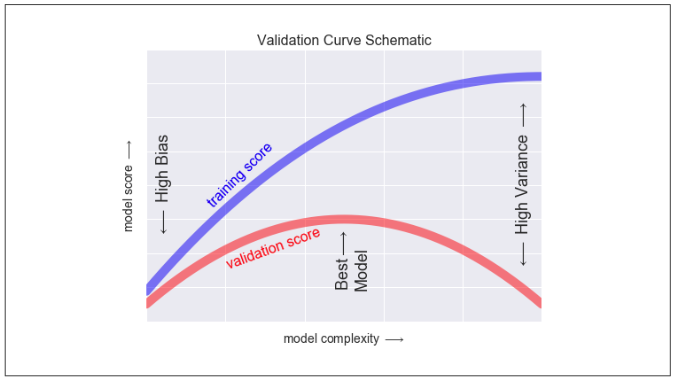

*Validation curve schematic (figure retrieved from the book)*


A model that underfits the data performs at a similar level on the training data and the validation data, whereas a model that overfits would have a very high score on the training data but a very low score on the training data.

### Validation curves in Scikit-Learn

The following example shows an examination of the validation curve for the class of *polynomial regression* models.

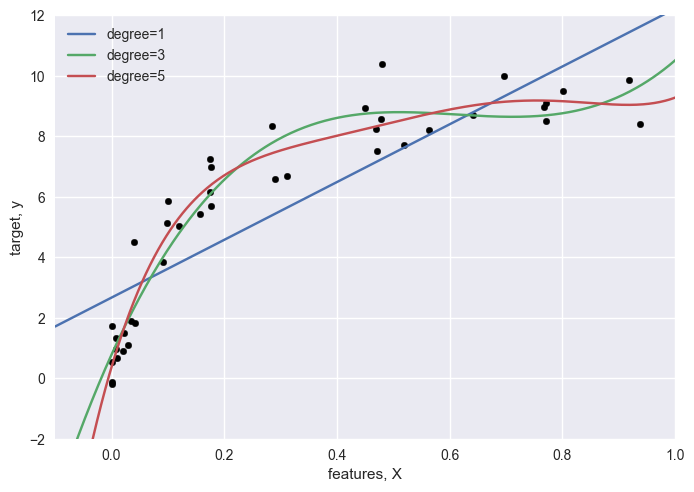

In [56]:
# 1. SELECT THE MODEL
# We'll use the PolynomialRegression model
# Included in this model is getting the polynomial features of the data
# So we have to create a pipeline that does polynomial features and regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.style.use(['seaborn-v0_8'])

# 2-3 SELECT HYPERPARAMETERS AND ARRANGE DATA
# the pipeline achieves pre-processing of data and regression at the same time
model = Pipeline([('features', PolynomialFeatures()),('regression', LinearRegression())])

# Code for generating training data obtained from book
def make_data(N, err=1.0, rseed=1):
# randomly sample the data
    rng = np.random.RandomState(rseed)
    X = rng.rand(N, 1) ** 2
    y = 10 - 1. / (X.ravel() + 0.1)
    if err > 0:
        y += err * rng.randn(N)
    return X, y
X, y = make_data(40)

# Test data
X_test = np.linspace(-0.1, 1.1, 500)[:, None]

# 4-5 FITTING THE MODEL AND PREDICTION
# Degree 1 (Straight Line)
for n in [1,3,5]:
    y_test = model.set_params(features__degree=n).fit(X,y).predict(X_test)
    plt.plot(X_test.ravel(), y_test, label=f'degree={n}')
    
plt.scatter(X.ravel(), y, color='black', s=22)
plt.xlabel('features, X')
plt.ylabel('target, y')
plt.xlim(-0.1,1.0)
plt.ylim(-2,12)
plt.legend(loc='best')
plt.show()

We can easily produce training and validation scores for different model complexities using the Scikit-Learn `validation_curve` function.

In this example, model complexity is controlled by varying the degree of the polynomial regression model.

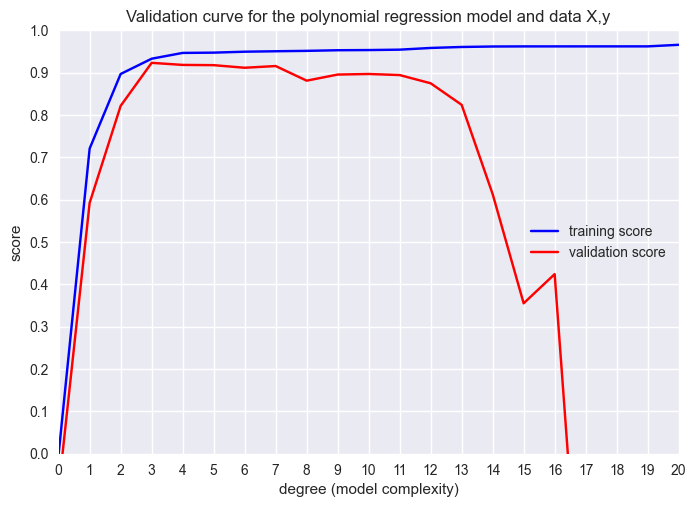

In [95]:
from sklearn.model_selection import validation_curve

# Generate polynomial degrees
degree = np.arange(0,21)

# Use the validation curve function to generate training and validation scores
# for different polynomial degrees
# Note: train_score and val_score are matrices with shape len(degree) x 7
# This is because we used cross-validation with 7 splits, and hence 7 fits for each polynomial degree.
train_score, val_score = validation_curve(
    model, X, y,
    param_name = 'features__degree',
    param_range = degree,
    cv = 7
)

# Plot the training and validation scores
# We'll combine the 7 scores of each polynomial by getting the median
plt.plot(degree, np.median(train_score, 1), color='blue', label='training score')
plt.plot(degree, np.median(val_score, 1), color='red', label='validation score')
plt.xlim(0,20)
plt.ylim(0,1)
plt.xticks(degree)
plt.yticks(np.arange(0,1.1,0.1))
plt.xlabel('degree (model complexity)')
plt.ylabel('score')
plt.title('Validation curve for the polynomial regression model and data X,y')
plt.legend(loc='best')
plt.show()

From the validation curve, we make the following observations:
1. The training score is always greater than the validation score. This is true for any validation curve: a model performs better on data that it knows.
2. For very low model complexity, the training data is underfit. The model is a poor predictor for training data and unknown data.
3. For very high model complexity, the training data is overfit. The model predicts the training data very well, but very poorly predicts unknown data.
4. On the range of complexities, there is a point resulting to the optimal score. At this complexity, the model predicts well both training and unknown data.

From the validation curve, we can see that the best model is a 3rd degree polynomial regression model.

Hence, the optimal trade-off between bias and variance is found for a 3rd degree polynomial.

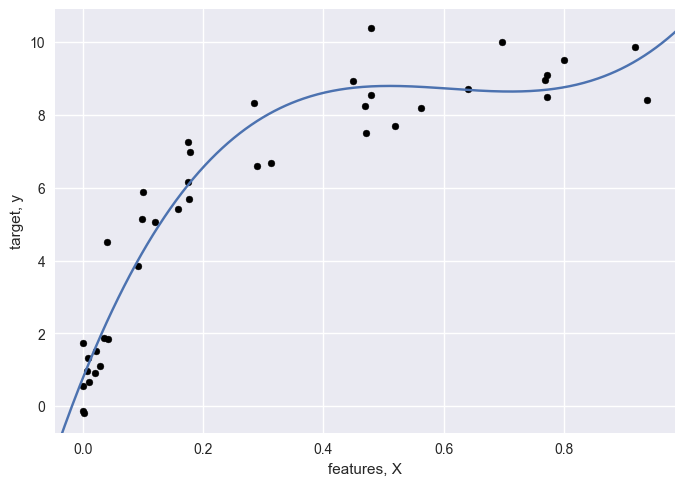

In [86]:
plt.scatter(X.ravel(), y, color='black', s=24)
lim = plt.axis()
y_test = model.set_params(features__degree=3).fit(X, y).predict(X_test)
plt.plot(X_test.ravel(), y_test)
plt.xlabel('features, X')
plt.ylabel('target, y')
plt.axis(lim)
plt.show()

## Learning Curves
the optimal model will generally depend on the size of the training sample.

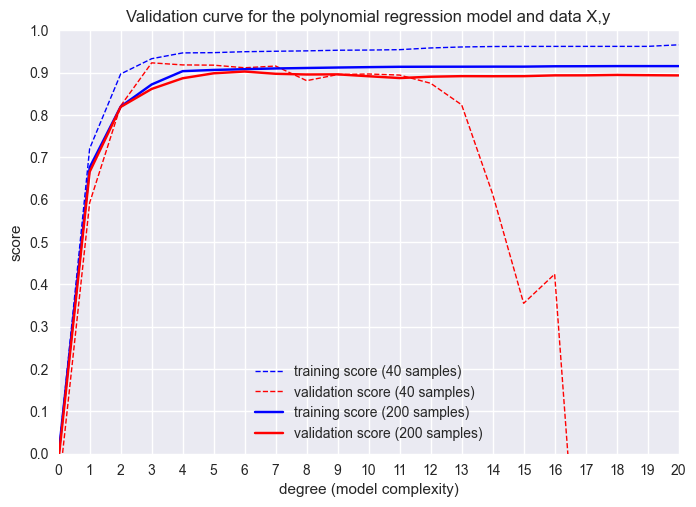

In [93]:
X2, y2 = make_data(200)

train_score2, val_score2 = validation_curve(
    model, X2, y2,
    param_name = 'features__degree',
    param_range = degree,
    cv = 7
)

plt.plot(degree, np.median(train_score, 1), color='blue', label='training score (40 samples)', ls='--', lw=1)
plt.plot(degree, np.median(val_score, 1), color='red', label='validation score (40 samples)', ls='--', lw=1)
plt.plot(degree, np.median(train_score2, 1), color='blue', label='training score (200 samples)')
plt.plot(degree, np.median(val_score2, 1), color='red', label='validation score (200 samples)')
plt.xlim(0,20)
plt.ylim(0,1)
plt.xticks(degree)
plt.yticks(np.arange(0,1.1,0.1))
plt.xlabel('degree (model complexity)')
plt.ylabel('score')
plt.title('Validation curve for the polynomial regression model and data X,y')
plt.legend(loc='best')
plt.show()

As can be seen from the plot, a larger dataset can support more complex models; with 200 samples, even at degree 20 the model does not exhibit overfitting.

Thus, the behavior of the validation curve has two important inputs:
- Model complexity
- Size of the training set

A learning curve is a plot of the training/validation score against the size of the training set. Some general behaviors of such curves are as follows:
- A model of given complexity will overfit a small dataset.
- A model of given complexity will underfit a large dataset.
- For any given model complexity and training set size, the validation score never exceeds the training score.

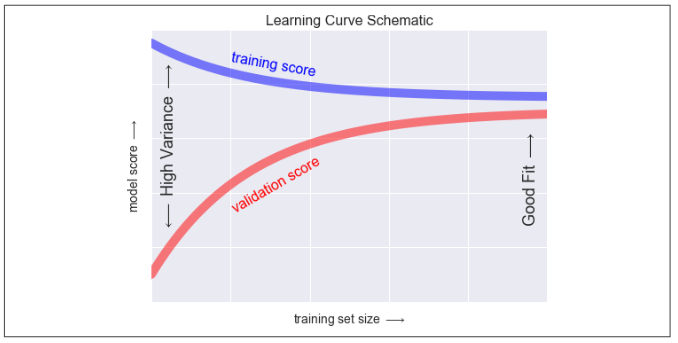

*Learning curve schematic (figure retrieved from the book)*

It is good to note that at sufficiently large training sets, the learning curve converges to a certain score. Once it reaches this point, increasing the size of the training set does not help -- the only way to optimize the model further is to increase model complexity.

### Learning curves in Scikit-Learn
In addition to the `validation_curve()` function, Scikit-Learn also offers a way to produce the scores of the learning curve with the `learning_curve()` function.

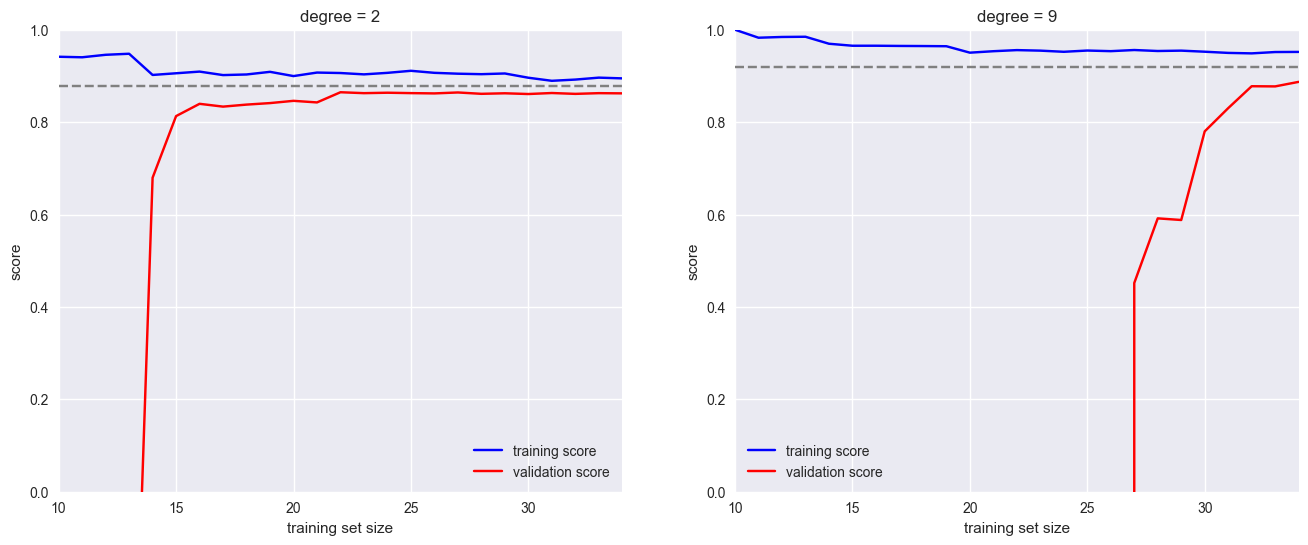

In [116]:
from sklearn.model_selection import learning_curve
fig, ax = plt.subplots(1,2,figsize=(16,6))

for i, degree in enumerate([2,9]):
    N, train_lc, val_lc = learning_curve(
        model.set_params(features__degree = degree),
        X, y,
        cv = 7,
        train_sizes = np.linspace(0.3,1,25)
    )

    ax[i].plot(N, np.mean(train_lc, 1), color='blue', label='training score')
    ax[i].plot(N, np.mean(val_lc, 1), color='red', label='validation score')
    ax[i].hlines(np.mean([train_lc[-1],val_lc[-1]]), N[0], N[-1], color='gray', ls='--')
    ax[i].legend()
    ax[i].set_title(f'degree = {degree}')
    ax[i].set_xlabel('training set size')
    ax[i].set_ylabel('score')
    ax[i].set_ylim(0,1)
    ax[i].set_xlim(N[0],N[-1])
plt.show()

## Validation in Practice: Grid Search

It is good to be able to see how model complexity and training set size influence the score of a model from visualizations such as the validation curve and the learning curve.

It would be more difficult, however, to do such visualizations when dealing with more hyperparameters that control model complexity -- more hyperparameters means more dimensions.

The most important thing is that we find the optimal complexity and training set size for a model. And, fortunately, the difficulty of achieving this is the same regardless of how many hyperparameters

We can obtain the best hyperparameters for a model using the Scikit-Learn `gridsearch()` function. Given a set of ranges for the hyperparameters, the grid search finds the values that results in the highest score.

In [120]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# Select model - Same as before, polynomial regression
model = Pipeline([
    ('scaler', StandardScaler()),
    ('features', PolynomialFeatures()),
    ('regression', LinearRegression())
])

# Define the hyperparameter ranges
param_grid = {
    'scaler': [StandardScaler(), 'passthrough'],
    'features__degree': np.arange(21),
    'regression__fit_intercept': [True, False]
}

# Create an instance of grid search
grid = GridSearchCV(model, param_grid, cv=7)

# Upon fitting, grid search will go through every combination of hyperparameters
# and identify the best_estimator_ -- the model with a hyperparameter combination that
# results in the highest score
grid.fit(X,y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'features__degree': array([ 0, 1..., 18, 19, 20]), 'regression__fit_intercept': [True, False], 'scaler': [StandardScaler(), 'passthrough']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",7
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each

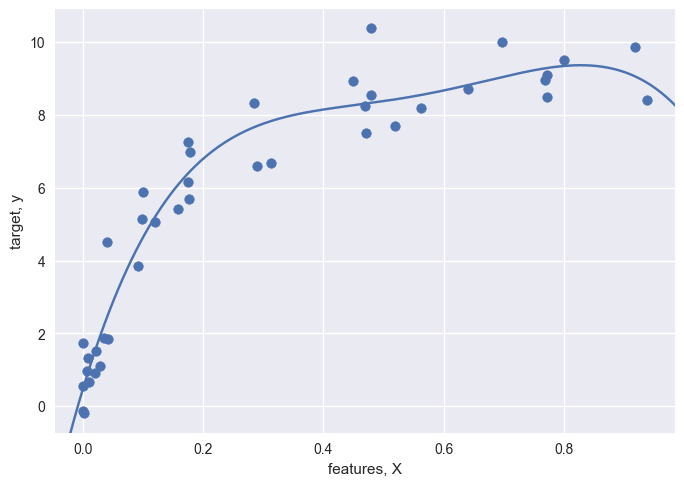

In [132]:
plt.scatter(X.ravel(), y)
lim = plt.axis()
y_test = grid.best_estimator_.fit(X,y).predict(X_test)
plt.plot(X_test.ravel(), y_test)
plt.axis(lim)
plt.xlabel('features, X')
plt.ylabel('target, y')
plt.show()